<a href="https://colab.research.google.com/github/Ritvik2090/credit-risk-analytics/blob/main/notebooks/03_model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Objective

## Model Building

### Objective

The objective of this notebook is to build machine learning models that predict whether a loan application will be approved based on applicant information.

The following models will be trained and evaluated:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

The models will later be compared to determine the best-performing approach.

# Step 1: Import Libraries

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Step 2: Load Cleaned Dataset

In [11]:
df = pd.read_csv("cleaned_data.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,0,1
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,0,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,0,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,0,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  614 non-null    object 
 1   Gender                   614 non-null    int64  
 2   Married                  614 non-null    int64  
 3   Dependents               614 non-null    int64  
 4   Education                614 non-null    int64  
 5   Self_Employed            614 non-null    int64  
 6   ApplicantIncome          614 non-null    int64  
 7   CoapplicantIncome        614 non-null    float64
 8   LoanAmount               614 non-null    float64
 9   Loan_Amount_Term         614 non-null    float64
 10  Credit_History           614 non-null    float64
 11  Loan_Status              614 non-null    int64  
 12  Property_Area_Semiurban  614 non-null    int64  
 13  Property_Area_Urban      614 non-null    int64  
dtypes: float64(4), int64(9), o

In [13]:
## Removing Loan_ID for model
df.drop(columns=["Loan_ID"], inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Dependents               614 non-null    int64  
 3   Education                614 non-null    int64  
 4   Self_Employed            614 non-null    int64  
 5   ApplicantIncome          614 non-null    int64  
 6   CoapplicantIncome        614 non-null    float64
 7   LoanAmount               614 non-null    float64
 8   Loan_Amount_Term         614 non-null    float64
 9   Credit_History           614 non-null    float64
 10  Loan_Status              614 non-null    int64  
 11  Property_Area_Semiurban  614 non-null    int64  
 12  Property_Area_Urban      614 non-null    int64  
dtypes: float64(4), int64(9)
memory usage: 62.5 KB


Everything is numeric.

# Step 3: Separate Features and Target

The target is:

**Loan_Status**

In [16]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

## Feature Selection

The target variable is **Loan_Status**, which indicates whether a loan application was approved.

All remaining variables are used as input features for prediction.

# Step 4: Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [18]:
## Verify
print(X_train.shape)
print(X_test.shape)

(491, 12)
(123, 12)


# Step 5: Build Logistic Regression

In [20]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Since we dont have standardized cells, we need to scale the data.

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
## after scaling we train the model again
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

# Step 6: Make Predictions

In [25]:
y_pred = log_model.predict(X_test)

# Step 7: Evaluate the Model

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7886178861788617


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [28]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[18 25]
 [ 1 79]]


In [29]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual Rejected", "Actual Approved"],
    columns=["Predicted Rejected", "Predicted Approved"]
)

cm_df

,Predicted Rejected,Predicted Approved
Actual Rejected,18,25
Actual Approved,1,79


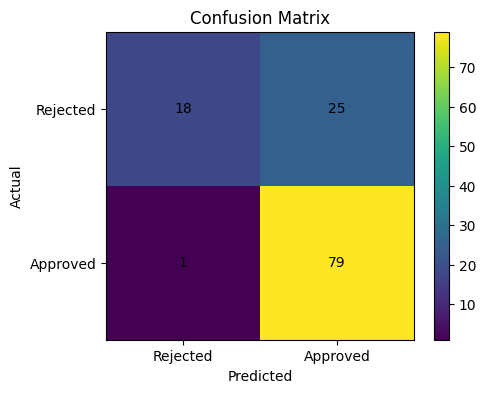

In [37]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)

plt.xticks([0,1], ["Rejected","Approved"])
plt.yticks([0,1], ["Rejected","Approved"])

plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model Evaluation

The trained Logistic Regression model is evaluated using the following metrics:

- **Accuracy**: Overall proportion of correct predictions.
- **Precision**: Percentage of predicted approvals that were actually approved.
- **Recall**: Percentage of actual approvals correctly identified by the model.
- **F1-Score**: Harmonic mean of precision and recall.
- **Confusion Matrix**: Shows the number of correct and incorrect predictions for each class.

# Logistic Regression Results

## Model Performance

The Logistic Regression model achieved an overall accuracy of **78.9%**.

The model demonstrated excellent performance in identifying approved loans, achieving a recall of **99%** for approved applicants. However, it correctly identified only **42%** of rejected applications.

This indicates that the model is biased toward predicting loan approvals, resulting in a relatively high number of false approvals. While this behavior maximizes approval detection, financial institutions may prefer a model that balances both approval and rejection predictions to better manage credit risk.

# Feature Importance

In [30]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
9,Credit_History,1.325382
10,Property_Area_Semiurban,0.446214
1,Married,0.298688
3,Education,0.147509
2,Dependents,0.127903
11,Property_Area_Urban,0.089175
4,Self_Employed,0.047632
8,Loan_Amount_Term,0.041008
0,Gender,-0.013352
5,ApplicantIncome,-0.032854


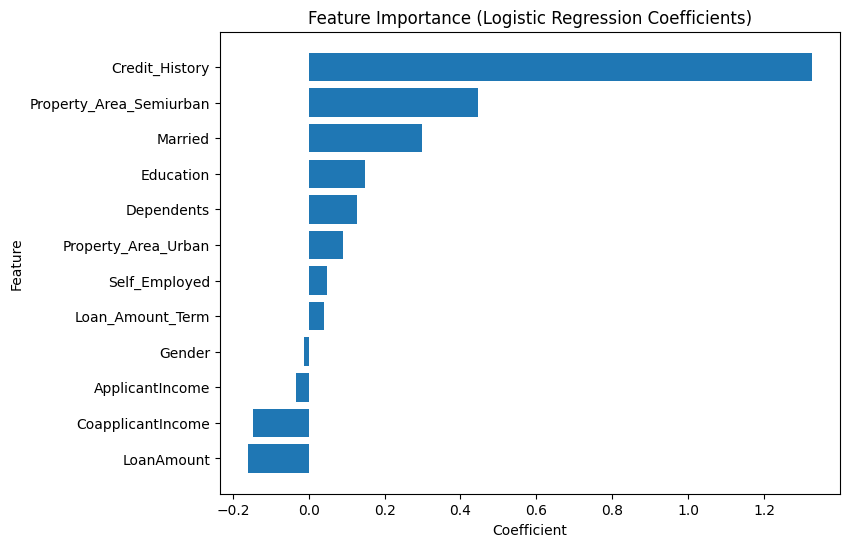

In [33]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values("Coefficient")

plt.figure(figsize=(8,6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Coefficient"]
)

plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

## Feature Importance

The Logistic Regression coefficients indicate how each feature influences the probability of loan approval.

Positive coefficients increase the likelihood of approval, while negative coefficients reduce it.

Among all features, Credit History had the strongest positive influence, which is consistent with the findings from the exploratory data analysis.

# Compare with Other Models

## Decision Tree Model

In [31]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7073170731707317


## Random Forest

In [32]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7560975609756098


## Comparison

In [34]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.788618
1,Decision Tree,0.707317
2,Random Forest,0.756098


# Conclusion

## Model Comparison

Three machine learning models were trained and evaluated on the cleaned loan dataset.

| Model | Accuracy |
|--------|---------:|
| Logistic Regression | 78.9% |
| Random Forest | 75.6% |
| Decision Tree | 70.7% |

Logistic Regression achieved the highest accuracy among the evaluated models. It also produced highly interpretable coefficients, making it suitable for understanding the factors influencing loan approval.

Decision Trees were easier to interpret visually but showed lower predictive performance. Random Forest improved upon the Decision Tree but did not outperform Logistic Regression on this dataset.

Considering both predictive performance and interpretability, Logistic Regression was selected as the final model.

# Business Recommendations

Based on the analysis and predictive models, the following recommendations can be made:

1. Credit history should remain one of the primary factors considered during loan evaluation.

2. Applicants with limited credit history may benefit from additional financial verification rather than automatic rejection.

3. Income alone should not be heavily weighted, as exploratory analysis showed only a weak relationship between income and loan approval.

4. A predictive model such as Logistic Regression can assist loan officers by providing an initial risk assessment while maintaining interpretability.

# Future Work

The current project establishes a baseline credit risk prediction model. Future enhancements may include:

- Hyperparameter tuning using GridSearchCV.
- Testing advanced ensemble models such as XGBoost and LightGBM.
- Addressing class imbalance using techniques such as SMOTE.
- Building an interactive Streamlit dashboard for loan prediction.
- Deploying the trained model as a web application.